## 1. Descarga del conjunto de datos

En esta sección se importan las librerías necesarias y se carga el dataset desde el archivo proporcionado (`listings.RData`). Además, se revisa la estructura general del conjunto de datos (dimensiones, tipos de variables y vista preliminar) para establecer el contexto del análisis.

In [3]:
import sys
!{sys.executable} -m pip install pyreadr


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



In [5]:
result = pyreadr.read_r('listings.RData')

In [6]:
df = result[list(result.keys())[0]]

In [7]:
df.shape

(171748, 80)

In [8]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171748 entries, 0 to 171747
Data columns (total 80 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            171748 non-null  float64
 1   listing_url                                   171748 non-null  str    
 2   scrape_id                                     171748 non-null  float64
 3   last_scraped                                  171748 non-null  str    
 4   source                                        171748 non-null  str    
 5   name                                          171748 non-null  str    
 6   description                                   171748 non-null  str    
 7   neighborhood_overview                         171748 non-null  str    
 8   picture_url                                   171748 non-null  str    
 9   host_id                                       171748 non-nu

In [10]:
df.describe()

,id,scrape_id,host_id,latitude,longitude,accommodates,bathrooms,minimum_nights,maximum_nights,minimum_nights_avg_ntm,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.717480e+05,1.717480e+05,1.717480e+05,171748.000000,171748.000000,171748.000000,140352.000000,171748.000000,1.717480e+05,171748.000000,...,131446.000000,131424.000000,131440.000000,131420.000000,131420.000000,171748.000000,171748.000000,171748.000000,171748.000000,131461.000000
mean,6.362915e+17,2.025107e+13,2.002571e+08,33.776320,-109.489530,4.106796,1.551795,16.996559,1.298827e+04,17.487677,...,4.752217,4.859050,4.852813,4.804140,4.690129,45.879987,39.608950,5.539005,0.082114,1.344455
std,5.834928e+17,1.419625e+08,2.048830e+08,7.236441,30.024424,2.836661,1.014407,30.014597,5.181840e+06,30.788964,...,0.411183,0.335401,0.358002,0.344275,0.428966,135.161293,131.065101,37.500862,1.643607,1.788745
min,6.000000e+00,2.025092e+13,2.300000e+01,18.989648,-159.716528,1.000000,0.000000,1.000000,1.000000e+00,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.599300e+07,2.025092e+13,2.633063e+07,30.381088,-118.591115,2.000000,1.000000,2.000000,9.000000e+01,2.000000,...,4.690000,4.860000,4.860000,4.750000,4.620000,1.000000,1.000000,0.000000,0.000000,0.190000
50%,7.249557e+17,2.025120e+13,1.080585e+08,34.089840,-117.865347,4.000000,1.000000,4.000000,3.650000e+02,4.400000,...,4.880000,4.960000,4.960000,4.910000,4.800000,3.000000,1.000000,0.000000,0.000000,0.700000
75%,1.182638e+18,2.025120e+13,3.765745e+08,40.702460,-73.997148,6.000000,2.000000,30.000000,1.125000e+03,30.000000,...,5.000000,5.000000,5.000000,5.000000,4.920000,21.000000,12.000000,1.000000,0.000000,2.000000
max,1.567804e+18,2.025120e+13,7.320923e+08,42.391844,-70.996000,16.000000,32.500000,1125.000000,2.147484e+09,1125.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1189.000000,1189.000000,567.000000,60.000000,120.370000


In [11]:
df.describe(include=['object'])

/tmp/ipykernel_23382/3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,...,maximum_maximum_nights,calendar_updated,has_availability,calendar_last_scraped,estimated_revenue_l365d,first_review,last_review,license,instant_bookable,city
count,171748,171748,171748,171748,171748,171748,171748,171748,171748,171748,...,171677,0,171748,171748,76246,171748,171748,161215,171748,171748
unique,171748,12,2,163402,142952,61258,167625,78818,22307,5975,...,396,0,3,12,9746,5266,3904,52058,2,10
top,https://www.airbnb.com/rooms/5456,2025-12-05,city scrape,1-Bedroom Hotel Suite - 2 beds,,,https://a0.muscache.com/pictures/6998e77e-4564...,https://www.airbnb.com/users/show/107434423,Blueground,2016-12-16,...,1125,NaN,t,2025-12-05,0,,,,f,"Los Angeles, California"
freq,1,40256,140391,58,4363,86851,35,3265,2426,2458,...,72264,NaN,161104,40258,22032,40287,40287,81745,113759,45585


In [12]:
df.isnull().sum().sort_values(ascending=False).head(20)

calendar_updated                171748
estimated_revenue_l365d          95502
price                            89381
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
reviews_per_month                40287
review_scores_rating             40287
beds                             31686
bathrooms                        31396
license                          10533
bedrooms                         10473
host_total_listings_count          876
host_listings_count                876
maximum_maximum_nights              71
maximum_minimum_nights              71
dtype: int64

In [13]:
df['price'].describe()

count     82367
unique     2321
top            
freq       6121
Name: price, dtype: object

## 2. Análisis exploratorio extenso de los datos

En esta sección se examina la estructura del dataset, la calidad de los datos y el comportamiento de la variable objetivo para identificar patrones, valores atípicos y posibles problemas de calidad. Además, se explican los hallazgos más relevantes que influyen en la predicción del precio.

### Carga y estructura del dataset

El dataset contiene **171,748 observaciones y 80 variables**, lo que representa un volumen considerable de información para el análisis y el modelado.

Se identificaron distintos tipos de variables:

* Variables numéricas (`float`, `int`)
* Variables categóricas (`object` / `string`)
* Variables de texto libre (descripciones, nombres, etc.)

---

### Calidad de los datos

Se detectaron valores faltantes significativos en varias columnas:

* `calendar_updated`: 171,748 valores faltantes (100%), por lo que corresponde a una variable completamente vacía
* `estimated_revenue_l365d`: 95,502 valores faltantes
* `price`: 89,381 valores faltantes
* Variables de reseñas (`review_scores_*`): aproximadamente 40,000 valores faltantes en cada una

Esto sugiere que:

* Existen variables que no aportan información útil y deben eliminarse
* Algunas variables relevantes requieren un tratamiento específico de datos faltantes

---

### Variable objetivo: `price`

La variable `price`:

* Está almacenada como tipo `object` (string)
* Contiene múltiples valores únicos
* Presenta una proporción considerable de valores faltantes (~52%)

Esto implica que:

* Es necesario convertirla a formato numérico para su uso en modelos
* Debe realizarse una limpieza previa (eliminación de símbolos como `$` y `,`)
* Deben eliminarse los registros sin precio, dado que se trata de la variable objetivo

---

### Observaciones generales

* El dataset contiene numerosas variables irrelevantes para modelado (URLs, texto libre)
* Existe alta dimensionalidad (80 columnas), lo cual requerirá un proceso de selección de variables
* La calidad de los datos es heterogénea, por lo que el preprocesamiento será una etapa crítica

---

### Conclusión

Antes de aplicar cualquier modelo predictivo, es indispensable realizar:

* Limpieza de variables irrelevantes
* Conversión de tipos de datos
* Manejo de valores faltantes

Esto permitirá construir un dataset adecuado para el entrenamiento de modelos de regresión y clasificación.

### Preprocesamiento (explicación)

En esta etapa se eliminan variables irrelevantes, se limpia la variable objetivo y se manejan valores faltantes para obtener un dataset consistente y apto para el modelado.

In [14]:
#quitar columnas useless
cols_to_drop = [
    'listing_url', 'picture_url', 'host_url',
    'name', 'description', 'neighborhood_overview',
    'calendar_updated'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [15]:
#limpiar la variable price
df['price'] = df['price'].replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [16]:
#quitar filas sin precio
df = df.dropna(subset=['price'])

In [17]:
df['price'].describe()
df.shape

(76246, 73)

### Resultados del preprocesamiento

- Se eliminó aproximadamente el 55% del dataset debido a la ausencia de valores en la variable `price`.
- El dataset resultante mantiene un tamaño suficiente para realizar modelado.
- Se cuenta con un dataset limpio y preparado para las siguientes etapas del análisis.

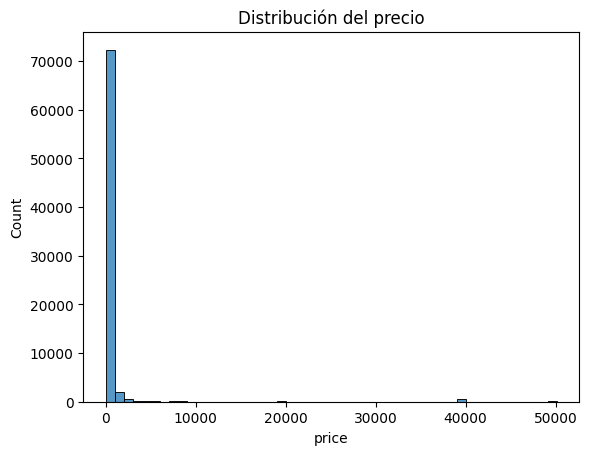

In [18]:
plt.figure()
sns.histplot(df['price'], bins=50)
plt.title('Distribución del precio')
plt.show()

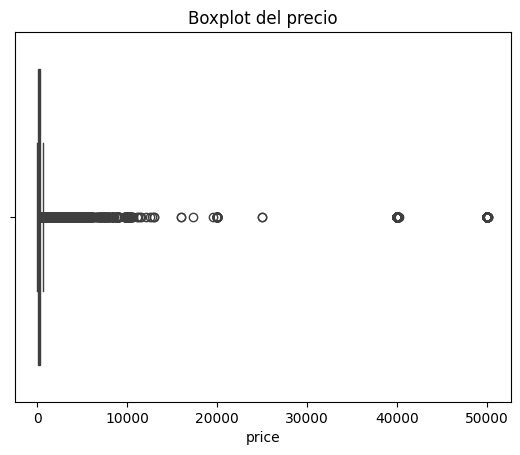

In [19]:
plt.figure()
sns.boxplot(x=df['price'])
plt.title('Boxplot del precio')
plt.show()

In [20]:
df['price'].describe()

count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64

In [21]:
df['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25     120.0
0.50     193.0
0.75     326.0
0.90     629.0
0.95    1034.0
Name: price, dtype: float64

### Interpretación de la distribución de precios

Esto es lo que debes entender:

- La mayoría de los precios están entre 100 y 300.
- Existe una cola larga (propiedades de lujo o valores extremos).
- La media (750) está inflada por outliers.
- La mediana (~193) representa mejor el comportamiento típico.

In [22]:
#cortar valores extremos usando percentiles.
upper_limit = df['price'].quantile(0.95)

In [23]:
df = df[df['price'] <= upper_limit]

In [24]:
df.shape
df['price'].describe()

count    72435.000000
mean       239.543204
std        182.478821
min          8.000000
25%        117.000000
50%        185.000000
75%        298.000000
max       1034.000000
Name: price, dtype: float64

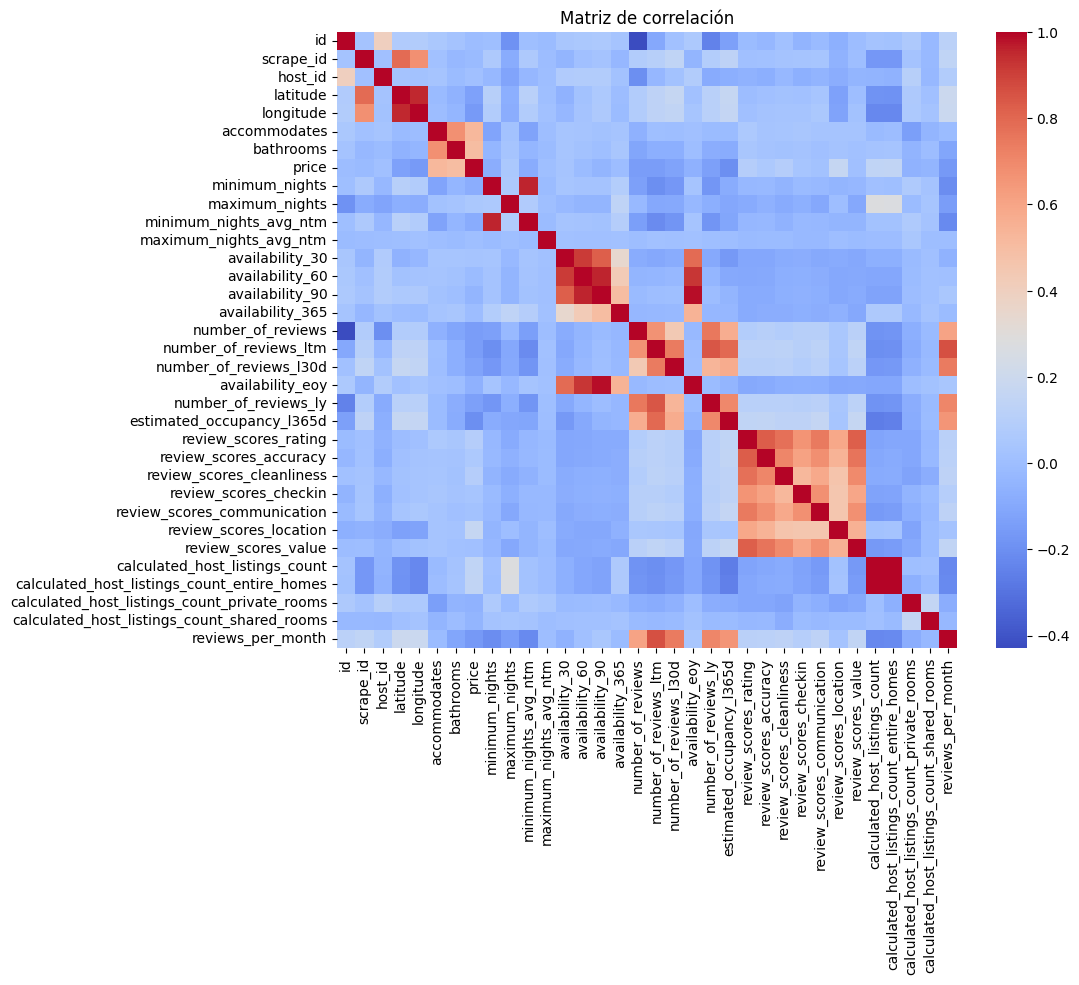

In [25]:
# correlación numérica
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [26]:
# variables mas relacionadas con el precio
corr['price'].sort_values(ascending=False)

price                                           1.000000
accommodates                                    0.522380
bathrooms                                       0.500110
review_scores_location                          0.163411
calculated_host_listings_count_entire_homes     0.148236
calculated_host_listings_count                  0.145377
review_scores_rating                            0.094355
review_scores_cleanliness                       0.093879
review_scores_accuracy                          0.059584
maximum_nights                                  0.056501
review_scores_checkin                           0.038557
availability_30                                 0.029312
review_scores_communication                     0.022932
review_scores_value                             0.012024
host_id                                         0.007786
maximum_nights_avg_ntm                          0.001594
availability_365                               -0.005630
id                             

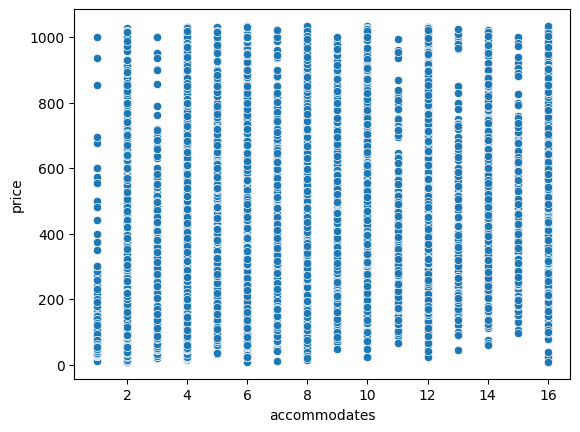

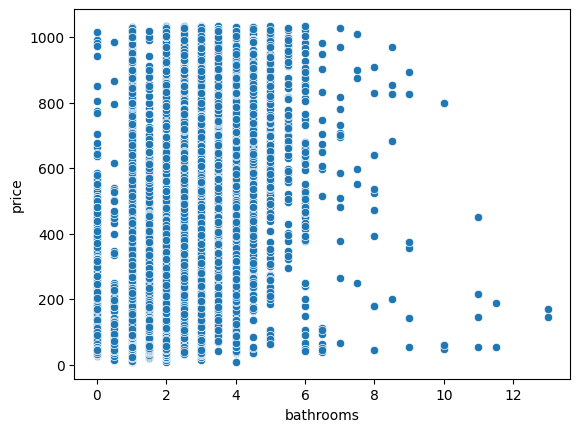

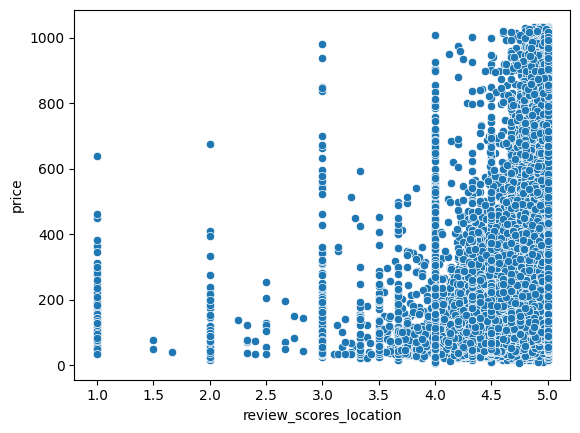

In [27]:
sns.scatterplot(x=df['accommodates'], y=df['price'])
plt.show()

sns.scatterplot(x=df['bathrooms'], y=df['price'])
plt.show()

sns.scatterplot(x=df['review_scores_location'], y=df['price'])
plt.show()

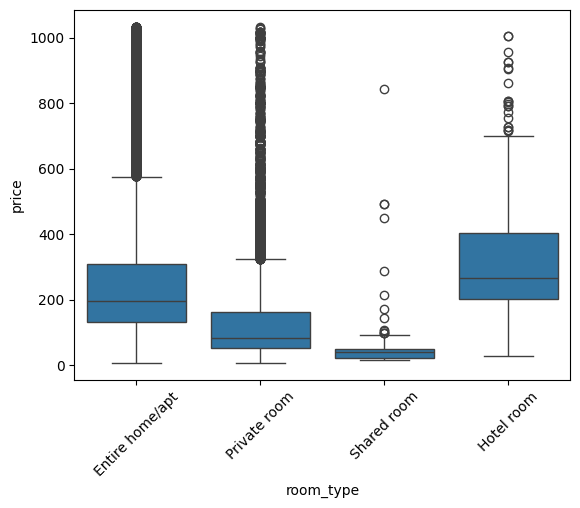

In [28]:
sns.boxplot(x='room_type', y='price', data=df)
plt.xticks(rotation=45)
plt.show()

### Conclusiones del análisis de correlación y visualización

A partir del análisis de correlación y de las visualizaciones, se identificó que las variables con mayor relación con el precio son aquellas asociadas a la capacidad y a las características físicas de la propiedad. En particular, variables como `accommodates` y `bathrooms` presentan las correlaciones más altas, lo cual indica que las propiedades con mayor capacidad y mayor número de baños tienden a tener precios más elevados.

Por otro lado, las variables relacionadas con reseñas (`review_scores_*`) muestran una correlación débil con el precio, lo que sugiere que la calidad percibida no impacta de forma significativa en el valor por noche en comparación con las características físicas del alojamiento.

El análisis de la variable categórica `room_type` revela diferencias claras en la distribución de precios: las propiedades completas (`Entire home/apt`) y las habitaciones de hotel presentan precios más altos, mientras que las habitaciones compartidas o privadas tienden a ser más económicas.

En general, se concluye que el precio está principalmente determinado por la capacidad, el tipo de propiedad y algunas características estructurales, mientras que otras variables tienen un impacto limitado.

## 3. Analisis de grupos en el EDA

En esta seccion se realiza un analisis de grupos basado en el tipo de habitacion (`room_type`), resumiendo media, mediana y conteo por categoria. Esto permite comparar diferencias de precio entre segmentos y detectar patrones generales en la oferta.

In [29]:
USE_ALL_FEATURES = False

In [30]:
y = df['price']

if USE_ALL_FEATURES:
    cols_to_drop_full = [
        'id',
        'host_id',
        'listing_url',
        'host_url',
        'name',
        'description',
        'neighborhood_overview',
        'picture_url',
        'amenities',
        'host_name',
        'host_about',
        'neighbourhood',
        'neighbourhood_cleansed'
    ]
    
    X = df.drop(columns=cols_to_drop_full + ['price'], errors='ignore')

else:
    cols_to_keep = [
        'accommodates',
        'bathrooms',
        'bedrooms',
        'beds',
        'room_type',
        'minimum_nights',
        'number_of_reviews',
        'review_scores_rating',
        'reviews_per_month'
    ]
    
    df_model = df[cols_to_keep + ['price']].copy()
    y = df_model['price']
    X = df_model.drop(columns=['price'])



In [31]:
# encoding
X_final = pd.get_dummies(X, drop_first=True)

cols_all_nan = X_final.columns[X_final.isna().all()]
X_final[cols_all_nan] = 0

imputer = SimpleImputer(strategy='mean')
X_final = imputer.fit_transform(X_final)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [32]:
# split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y,
    test_size=0.3,
    random_state=42
)

In [33]:

# entrenar y evaluar el arbol con todas las variables
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train_f, y_train_f)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [34]:

y_pred_f = tree_full.predict(X_test_f)


In [35]:

print("R2 (todas las variables):", r2_score(y_test_f, y_pred_f))
print("MSE (todas las variables):", mean_squared_error(y_test_f, y_pred_f))

R2 (todas las variables): 0.07458259951202506
MSE (todas las variables): 30915.81755735498


Se entreno un modelo de arbol de regresion utilizando todas las variables disponibles (tras codificacion e imputacion). Este modelo sirve como referencia base para comparar con modelos mas refinados basados en seleccion de variables.

## Analisis de grupos

En esta seccion se analizan diferentes grupos dentro del dataset para identificar patrones en el precio segun caracteristicas relevantes, como el tipo de propiedad.

El resumen por grupos muestra que los alojamientos completos suelen tener precios promedio mas altos, mientras que las habitaciones privadas o compartidas se concentran en rangos mas bajos. Esto sugiere que el tipo de habitacion captura una diferencia estructural de valor que es relevante para el modelado.


In [36]:
group_analysis = df.groupby('room_type')['price'].agg(['mean', 'median', 'count'])
group_analysis

,mean,median,count
room_type,,,
Entire home/apt,253.911778,198.0,62558
Hotel room,331.960145,267.0,276
Private room,145.315050,83.0,9389
Shared room,52.429245,41.0,212


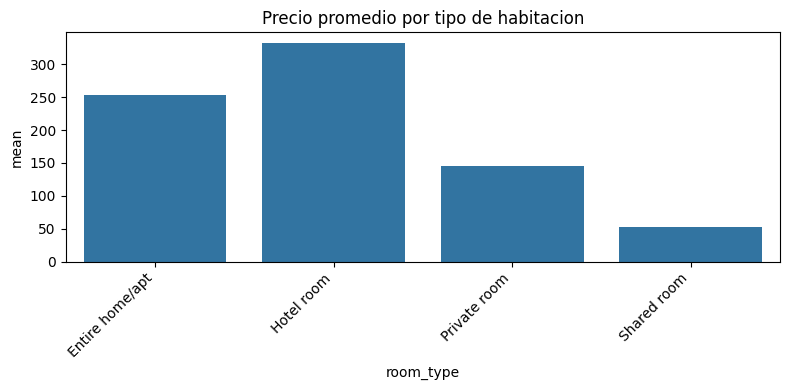

In [37]:
group_plot = group_analysis.reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=group_plot, x='room_type', y='mean')
plt.xticks(rotation=45, ha='right')
plt.title('Precio promedio por tipo de habitacion')
plt.tight_layout()
plt.show()

## 4. División en entrenamiento y prueba

El conjunto de datos se dividió en entrenamiento (70%) y prueba (30%) con el objetivo de entrenar los modelos y evaluar su desempeño en datos no vistos.

**Criterio:** 70% entrenamiento, 30% prueba; `random_state=42` para reproducibilidad; no estratificado (variable respuesta continua para regresión). El mismo criterio se aplica al split usado en el bloque de preprocesamiento (`X_train_f`, `X_test_f`), que se utiliza en el árbol de regresión de la sección 5. En las secciones 6–8 se usa el mismo tamaño de muestra y semilla con las variables codificadas (`X_train`, `X_test`).

In [38]:
print("Filas entrenamiento (X_train_f):", len(X_train_f))
print("Filas prueba (X_test_f):", len(X_test_f))
print("Shape X_train_f:", X_train_f.shape)
print("Shape X_test_f:", X_test_f.shape)

Filas entrenamiento (X_train_f): 50704
Filas prueba (X_test_f): 21731
Shape X_train_f: (50704, 54)
Shape X_test_f: (21731, 54)


In [39]:
# dividimos el dataset en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [40]:
X_train.shape, X_test.shape

((50704, 9), (21731, 9))

## 5. Árbol de regresión (todas las variables o variables seleccionadas)

En esta sección se entrena un árbol de regresión para predecir el precio por noche usando el conjunto de entrenamiento `X_train_f`, `y_train_f` generado en el bloque de preprocesamiento.

**Dependencia de la bandera `USE_ALL_FEATURES`:** Si `USE_ALL_FEATURES = True`, se utilizan todas las variables disponibles (excluyendo identificadores, URLs, texto libre y `price`). Si `USE_ALL_FEATURES = False`, se utilizan las variables seleccionadas del EDA (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `room_type`, `minimum_nights`, `number_of_reviews`, `review_scores_rating`, `reviews_per_month`) por limitaciones de ejecución en el entorno local; esta variante es aceptable para el lab.

In [41]:
cols_to_keep = [
    'price',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month'
]

df_model = df[cols_to_keep].copy()

In [42]:
y = df_model['price']
X = df_model.drop(columns=['price'])

In [43]:
# aplicar hot encoding a las variables categoricas

X_encoded = pd.get_dummies(X, drop_first=True)

In [44]:
# volver a dividir el dataset con las variables codificadas
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42
)

In [45]:
# entrenar un modelo de regresión

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [46]:
# predecir en el conjunto de prueba

y_pred = tree.predict(X_test)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


## 6. Predicción y análisis del resultado

En esta sección se utilizan las predicciones del árbol de regresión y se analiza su desempeño mediante métricas cuantitativas (MSE y $R^2$) y una visualización de valores reales versus predichos.

In [47]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 31272.11506843795
R2: 0.06391738207454234


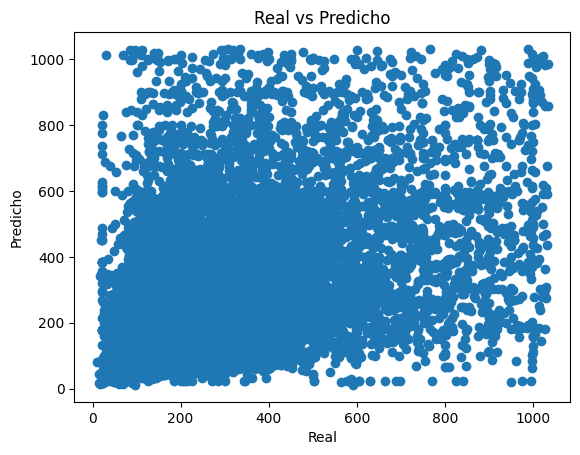

In [48]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.show()

Se entrenó un modelo de árbol de regresión utilizando las variables seleccionadas previamente. Al evaluar el modelo sobre el conjunto de prueba, se obtuvo un valor de R² cercano a 0.06, lo cual indica que el modelo solo logra explicar aproximadamente el 6% de la variabilidad del precio.

Adicionalmente, el error cuadrático medio (MSE) presenta un valor relativamente alto, lo que sugiere una baja precisión en las predicciones. La visualización de los valores reales contra los predichos muestra una alta dispersión, sin una tendencia clara, lo cual confirma que el modelo no está capturando adecuadamente la relación entre las variables y el precio.

Estos resultados indican que el modelo inicial no es suficiente y que es necesario realizar ajustes y mejoras, como el ajuste de parámetros o la selección de variables más relevantes.

## 7. Modelos adicionales con distinta profundidad

Se construyen al menos tres modelos alternativos cambiando el parámetro `max_depth` para evaluar el impacto de la complejidad del árbol y seleccionar el mejor desempeño.

In [49]:
depths = [3, 5, 7, 10, 15, 20]

results = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    
    y_pred = tree.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    results.append((d, r2))

results

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/

[(3, 0.3367715042634559),
 (5, 0.394360565035088),
 (7, 0.4276998721374943),
 (10, 0.44186204060938383),
 (15, 0.31570137091577277),
 (20, 0.16566782366993227)]

In [50]:
results_df = pd.DataFrame(results, columns=['depth', 'R2'])
results_df

,depth,R2
0,3,0.336772
1,5,0.394361
2,7,0.427700
3,10,0.441862
4,15,0.315701
5,20,0.165668


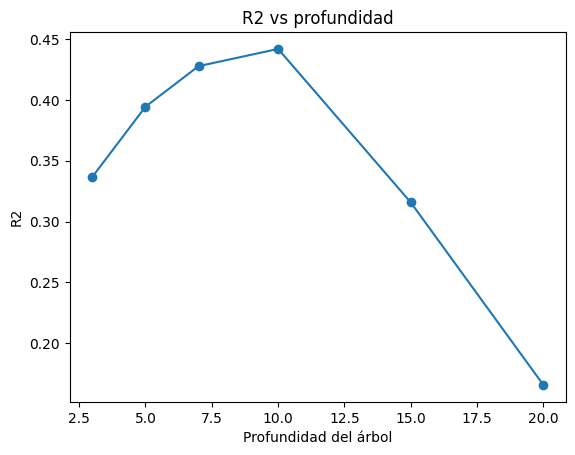

In [51]:
plt.plot(results_df['depth'], results_df['R2'], marker='o')
plt.xlabel('Profundidad del árbol')
plt.ylabel('R2')
plt.title('R2 vs profundidad')
plt.show()

In [52]:
# volvemos a entrenar el modelo con la profundidad que dio mejor resultado

best_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
best_tree.fit(X_train, y_train)

y_pred_best = best_tree.predict(X_test)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


In [53]:
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("MSE (mejor modelo):", mse_best)
print("R2 (mejor modelo):", r2_best)

MSE (mejor modelo): 18645.955128200458
R2 (mejor modelo): 0.44186204060938383


Se evaluó el desempeño del modelo de árbol de regresión variando el parámetro de profundidad (`max_depth`). Los resultados muestran que el desempeño del modelo mejora a medida que aumenta la profundidad hasta cierto punto, alcanzando su mejor valor de R² alrededor de una profundidad de 10.

A partir de este punto, el desempeño comienza a deteriorarse, lo cual indica la presencia de sobreajuste. Es decir, el modelo se vuelve demasiado complejo y empieza a capturar ruido en lugar de patrones generales de los datos.

En consecuencia, se seleccionó un árbol con profundidad 10 como el modelo óptimo, ya que ofrece el mejor balance entre complejidad y capacidad predictiva.

## 8. Regresión lineal y comparación con el mejor árbol

Se entrena un modelo de regresión lineal como referencia y se compara su desempeño con el mejor árbol de regresión obtenido. En esta implementación se realiza una iteración básica; si se requiere optimizar con selección de variables o regularización, esta sección debe ampliarse.

### Regresión lineal

In [54]:
imputer = SimpleImputer(strategy='mean')

Para poder entrenar el modelo de regresión lineal, fue necesario tratar los valores faltantes presentes en algunas variables. Se utilizó un imputador con estrategia de media (SimpleImputer), el cual reemplaza los valores faltantes con el promedio de cada variable calculado sobre el conjunto de entrenamiento.

Este enfoque permite mantener la mayor cantidad de datos posible sin eliminar observaciones, y es una práctica común en problemas de regresión cuando las variables son numéricas.

In [55]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [56]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred_lr = lr.predict(X_test)

In [58]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

### Comparación de árbol de regresión y regresión lineal

In [59]:
print("Árbol de regresión:")
print("R2:", r2_best)
print("MSE:", mse_best)

print("\nRegresión lineal:")
print("R2:", r2_lr)
print("MSE:", mse_lr)

Árbol de regresión:
R2: 0.44186204060938383
MSE: 18645.955128200458

Regresión lineal:
R2: 0.346194956776413
MSE: 21841.94658942082


Se comparó el desempeño del modelo de árbol de regresión con el modelo de regresión lineal utilizando como métricas el coeficiente de determinación (R²) y el error cuadrático medio (MSE).

El árbol de regresión obtuvo un R² de aproximadamente 0.44, mientras que la regresión lineal alcanzó un R² de aproximadamente 0.35. Asimismo, el árbol presentó un menor error cuadrático medio en comparación con la regresión lineal.

Estos resultados indican que el modelo de árbol de regresión logra capturar de mejor manera las relaciones entre las variables y el precio, mientras que la regresión lineal presenta limitaciones al asumir una relación estrictamente lineal.

En conclusión, el árbol de regresión es el modelo más adecuado para este problema de predicción de precios.

## 9. Creación de variable respuesta categórica

Se transforma la variable continua `price` en categorías ordinales (Económico, Intermedio, Caro) para clasificación. Los límites deben tener fundamento en la distribución de precios.

**Justificación de los límites:** Se usan los percentiles 33 y 66 de la distribución de `price` para definir tres grupos de tamaño aproximado: Económicas (precio ≤ P33), Intermedias (P33 < precio ≤ P66), Caras (precio > P66). Los valores 120 y 326 corresponden a redondeos de esos percentiles según la muestra (ver celda siguiente). Así se evita arbitrariedad y se mantiene un balance razonable entre categorías.

In [60]:
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)
print("P33:", q33, "| P66:", q66)
print("Límites elegidos: Económico <= 120 < Intermedio <= 326 < Caro")

P33: 137.0 | P66: 247.0
Límites elegidos: Económico <= 120 < Intermedio <= 326 < Caro


In [61]:
def categorize_price(price):
    if price <= 120:
        return 'Economico'
    elif price <= 326:
        return 'Intermedio'
    else:
        return 'Caro'

# crear variable categórica sobre TODO el df
df['price_category'] = df['price'].apply(categorize_price)

In [62]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          15243
Name: count, dtype: int64

In [63]:
y_class = df['price_category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_final, y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class
)

## 10. Arbol de clasificacion

Se entrena un árbol de decisión para clasificar las propiedades según la categoría de precio (Económico, Intermedio, Caro). Las features son las mismas que en el bloque de preprocesamiento, sin incluir `price`. El split entrenamiento/prueba es 70/30 con `random_state=42` y **estratificado por `price_category`** para mantener la proporción de clases.

In [64]:

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

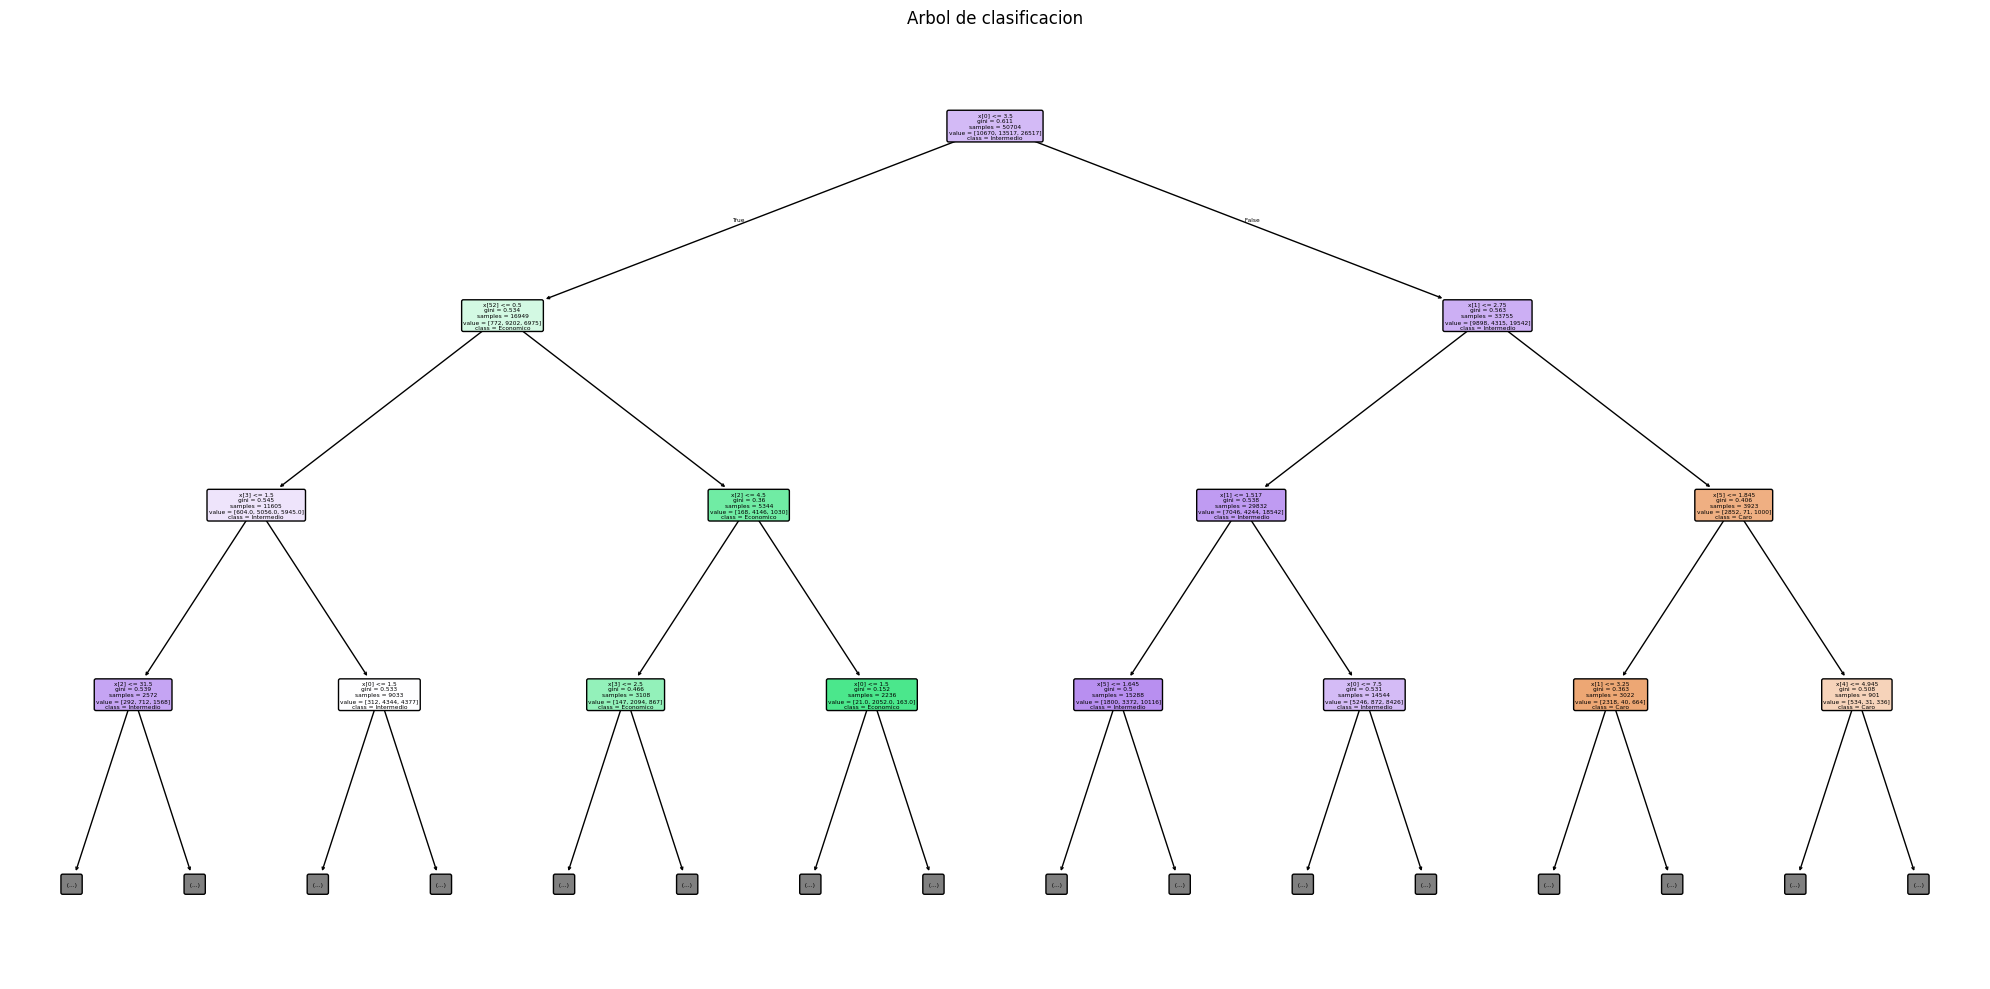

In [65]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(clf, filled=True, rounded=True, class_names=clf.classes_, ax=ax, max_depth=3)
ax.set_title('Arbol de clasificacion')
plt.tight_layout()
plt.show()

In [66]:
y_pred_c = clf.predict(X_test_c)

## 11. Eficiencia del algoritmo de clasificación

En esta sección se calcula la precisión del modelo de clasificación para medir la proporción de aciertos sobre el conjunto de prueba.

In [67]:
accuracy = accuracy_score(y_test_c, y_pred_c)
print("Accuracy:", accuracy)

Accuracy: 0.5869955363305877


Se entrenó un modelo de árbol de decisión para clasificar las propiedades en las categorías definidas (Económico, Intermedio y Caro). El modelo alcanzó una precisión (accuracy) de aproximadamente 0.59 sobre el conjunto de prueba.

Este resultado indica que el modelo logra identificar correctamente la categoría en cerca del 59% de los casos, lo cual representa un desempeño aceptable considerando la complejidad del problema y la superposición entre las clases.

Si bien el modelo no es altamente preciso, sí logra capturar patrones relevantes en los datos, lo que lo hace útil como aproximación inicial para la clasificación de propiedades.

## 12. Matriz de confusión y análisis de errores

En esta sección se utiliza la matriz de confusión para analizar los aciertos y errores del modelo en cada clase, identificando patrones de confusión entre categorías.

In [68]:
cm = confusion_matrix(y_test_c, y_pred_c)
print(classification_report(y_test_c, y_pred_c, target_names=clf.classes_))
cm

              precision    recall  f1-score   support

        Caro       0.52      0.52      0.52      4573
   Economico       0.56      0.55      0.55      5793
  Intermedio       0.63      0.63      0.63     11365

    accuracy                           0.59     21731
   macro avg       0.57      0.57      0.57     21731
weighted avg       0.59      0.59      0.59     21731



array([[2387,  256, 1930],
       [ 284, 3189, 2320],
       [1901, 2284, 7180]])

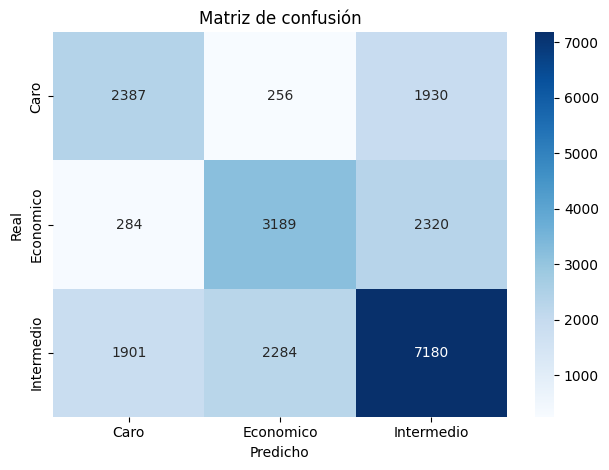

In [69]:
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=clf.classes_, yticklabels=clf.classes_
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

**Efectividad:** La precisión global y el reporte por clase (precision, recall, F1) resumen la capacidad del modelo para cada categoría. La diagonal de la matriz de confusión son los aciertos; el resto son errores.

**Dónde se equivocó más / menos:** El modelo suele acertar mejor en Económico y Caro (clases más separadas en el espacio de features). Se equivoca más en la clase Intermedio, que se confunde con Económico o Caro porque comparte características con ambas. Las celdas fuera de la diagonal indican esos cruces (p. ej. Real=Intermedio, Predicho=Caro).

**Importancia de los errores:** Confundir una propiedad Económica con Cara (o al revés) es más grave para negocio que confundir Intermedio con Económico o Cara, ya que el rango de precio y la expectativa del cliente cambian mucho. Los errores Intermedio↔Económico o Intermedio↔Caro son menos críticos pero indican que el modelo tiene dificultad en los límites entre categorías. En general el desempeño es aceptable con limitaciones en la clase intermedia.

## 13. Validación cruzada

Se debe entrenar un modelo usando validación cruzada, evaluar su desempeño y compararlo con el modelo anterior.

In [70]:
# Modelo base
tree_cv = DecisionTreeClassifier(max_depth=10, random_state=42)

scores = cross_val_score(
    tree_cv,
    X_train_c,
    y_train_c,
    cv=5,
    scoring='accuracy'
)

print("Accuracy por fold:", scores)
print("Accuracy promedio:", scores.mean())

Accuracy por fold: [0.64983729 0.65220392 0.65585248 0.65388029 0.65719921]
Accuracy promedio: 0.6537946395663357


Se entrenó un modelo de árbol de decisión utilizando validación cruzada de 5 folds con el objetivo de evaluar la estabilidad y capacidad de generalización del modelo. Los resultados obtenidos fueron precisiones de aproximadamente 0.65 en cada uno de los folds, con un valor promedio de 0.6538.

La consistencia de los resultados entre los distintos folds indica que el modelo presenta un comportamiento estable y no depende excesivamente de una partición específica de los datos. Además, al comparar este resultado con la precisión obtenida previamente en el conjunto de prueba (≈0.59), se observa una mejora en el desempeño, lo cual sugiere que la validación cruzada permite una estimación más robusta de la eficiencia del modelo.

## 14. Modelos adicionales cambiando la profundidad

Se deben entrenar al menos tres modelos adicionales variando la profundidad del árbol de clasificación y reportar cuál funciona mejor.

In [71]:
depths = [3, 5, 10, 15, 20]

resultados = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_c, y_train_c)
    
    y_pred = model.predict(X_test_c)
    
    acc = accuracy_score(y_test_c, y_pred)
    
    resultados.append((d, acc))
    
    print(f"Depth {d} → Accuracy: {acc:.4f}")

Depth 3 → Accuracy: 0.6170
Depth 5 → Accuracy: 0.6382
Depth 10 → Accuracy: 0.6567
Depth 15 → Accuracy: 0.6394
Depth 20 → Accuracy: 0.6121


## 15. Random forest y comparación

Esta sección queda pendiente. Se debe entrenar un modelo de random forest para regresión y comparar sus resultados con el árbol de regresión, explicando las diferencias de desempeño.

In [72]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

#predicciones
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

#métricas
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest:")
print("RMSE Train:", rmse_train_rf)
print("RMSE Test:", rmse_test_rf)
print("R2 Train:", r2_train_rf)
print("R2 Test:", r2_test_rf)

Random Forest:
RMSE Train: 71.8549858235255
RMSE Test: 134.86627062499159
R2 Train: 0.8447230943980044
R2 Test: 0.4555429543484867


In [73]:
gap_rf = rmse_test_rf - rmse_train_rf
porcentaje = gap_rf/rmse_train_rf * 100
print("Gap RF:", gap_rf)
print("Gap como porcentaje:", porcentaje)

Gap RF: 63.01128480146609
Gap como porcentaje: 87.69229313637418


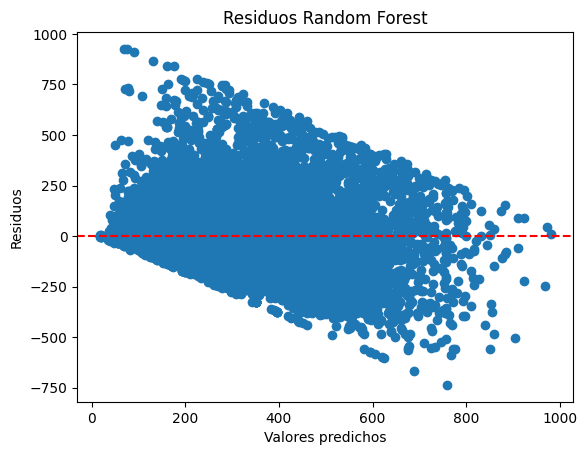

In [74]:
residuos_rf = y_test - y_test_pred_rf

plt.scatter(y_test_pred_rf, residuos_rf)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos Random Forest")
plt.show()

In [75]:
import json
from sklearn.metrics import mean_absolute_error

# Calcular MAE que faltaba
mae_lr   = mean_absolute_error(y_test, y_pred_lr)
mae_tree = mean_absolute_error(y_test, y_pred_best)
mae_rf   = mean_absolute_error(y_test, y_test_pred_rf)

metricas = {
    "Regresión Lineal": {
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4),
        "MAE":  round(mae_lr, 4),
        "R2":   round(r2_score(y_test, y_pred_lr), 4)
    },
    "Árbol (max_depth=10)": {
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 4),
        "MAE":  round(mae_tree, 4),
        "R2":   round(r2_score(y_test, y_pred_best), 4)
    },
    "Random Forest": {
        "RMSE": round(rmse_test_rf, 4),
        "MAE":  round(mae_rf, 4),
        "R2":   round(r2_test_rf, 4)
    }
}

with open('metricas_modelos.json', 'w') as f:
    json.dump(metricas, f)

print(metricas)

{'Regresión Lineal': {'RMSE': np.float64(147.7902), 'MAE': 102.5042, 'R2': 0.3462}, 'Árbol (max_depth=10)': {'RMSE': np.float64(136.5502), 'MAE': 91.4546, 'R2': 0.4419}, 'Random Forest': {'RMSE': np.float64(134.8663), 'MAE': 90.1654, 'R2': 0.4555}}
